In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize, integrate

$$
E + S \underset{k_{-1}}{\overset{k_1}{\rightleftharpoons}} ES \overset{k_{cat}}{\rightarrow} E + P
$$

$$
\begin{align}
\frac{\mathrm{d}E}{\mathrm{d}t} &= - k_1 E\cdot S + k_{-1} ES + k_{cat} ES \\
\frac{\mathrm{d}S}{\mathrm{d}t} &= - k_1 E\cdot S + k_{-1} ES \\
\frac{\mathrm{d}ES}{\mathrm{d}t} &= + k_1 E\cdot S - k_{-1} ES - k_{cat} ES \\
\frac{\mathrm{d}P}{\mathrm{d}t} &= + k_{cat} ES
\end{align}
$$

$$
\frac{\mathrm{d}ES}{\mathrm{d}t} = 0, E_{tot} = E + ES, E \ll S, k_M = \frac{k_{-1} + k_{cat}}{k_1}, v_\max = k_2 E_{tot}
$$

$$
\begin{align}
\frac{\mathrm{d}ES}{\mathrm{d}t} &= + k_1 E\cdot S - k_{-1} ES - k_{cat} ES = 0 \\
\Leftrightarrow k_1 (E_{tot} - ES)\cdot S &= (k_{-1} + k_{cat}) ES \\
\Leftrightarrow \frac{E_{tot}S}{ES} - S &= \frac{k_{-1} + k_{cat}}{k_1} = k_M \\
\Leftrightarrow {ES} &= \frac{E_{tot}S}{k_M + S} \\
\Leftrightarrow v &= k_2 ES = \frac{v_\max S}{k_M + S}
\end{align}
$$

$$
\begin{align}
v &= \frac{v_\max S}{k_M + S} \\
\Leftrightarrow \frac{1}{v} &= \frac{k_M}{v_\max}\frac{1}{S} + \frac{1}{v_\max}
\end{align}
$$

In [2]:
def system(t, x, k1, k1inv, kcat):
    return np.array([
        - k1 * x[0] * x[1] + k1inv * x[2] + kcat * x[2],
        - k1 * x[0] * x[1] + k1inv * x[2],
        + k1 * x[0] * x[1] - k1inv * x[2] - kcat * x[2],
        + kcat * x[2]
    ])

In [3]:
t = np.linspace(0, 1000, 200)

In [4]:
x0 = np.array([1e-6, 1e-2, 0.0, 0.0])

In [5]:
ks = np.array([1e-1, 1e-2, 1e-3])

In [6]:
Ss = np.linspace(1e-1, 1, 25)

In [7]:
vs = []
sols = []
for S in Ss:
    x0 = np.array([1e-6, S, 0.0, 0.0])
    solution = integrate.solve_ivp(system, [t.min(), t.max()], y0=x0, args=ks, t_eval=t, atol=1e-16, rtol=1e-12)
    sols.append(solution)
    v = system(t, solution.y, *ks)
    vs.append(v[3,-1])
vs = np.array(vs)

In [8]:
def model(x, vmax, kM):
    return vmax * x / (x + kM)

In [9]:
popt, pcov = optimize.curve_fit(model, Ss, vs)
vhat = model(Ss, *popt)

In [10]:
np.sum(((vhat[1:] - vs[1:]) / vs[1:]) ** 2)

np.float64(5.97304901963056e-13)

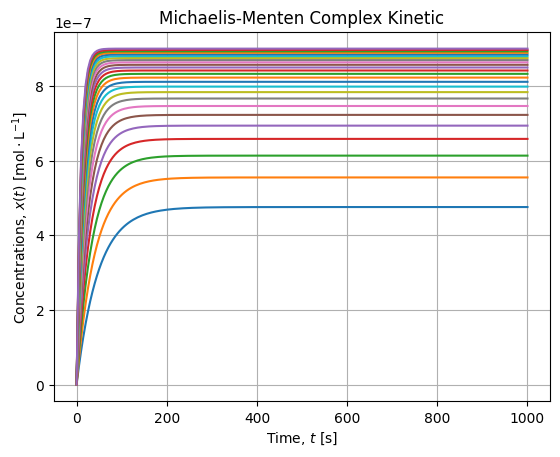

In [11]:
fig, axe = plt.subplots()
for sol in sols:
    axe.plot(t, sol.y[2])
axe.set_title("Michaelis-Menten Complex Kinetic")
axe.set_xlabel("Time, $t$ $[\mathrm{s}]$")
axe.set_ylabel("Concentrations, $x(t)$ $[\mathrm{mol\cdot L^{-1}}]$")
axe.grid()

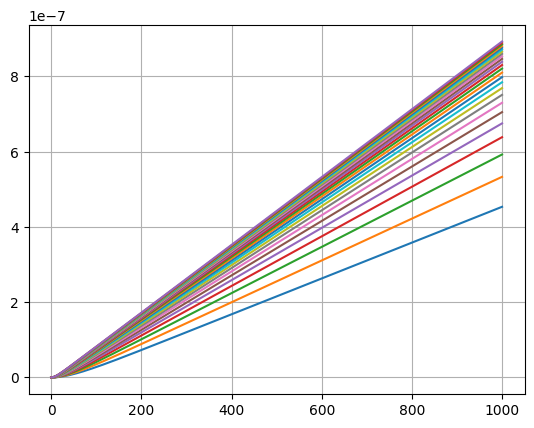

In [12]:
fig, axe = plt.subplots()
for sol in sols:
    axe.plot(t, sol.y[3])
axe.grid()

In [13]:
Slin = np.linspace(Ss.min(), Ss.max(), 200)
vlin = model(Slin, *popt)

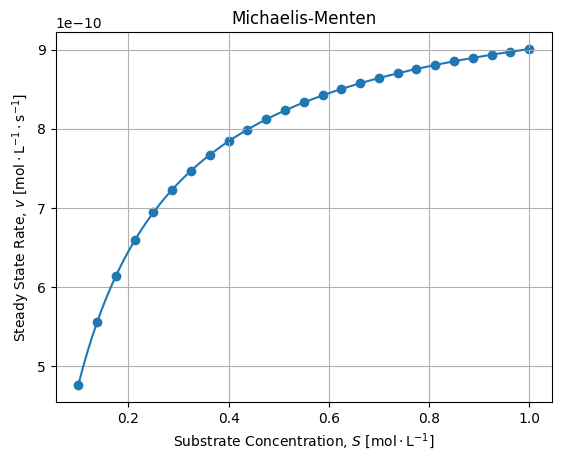

In [14]:
fig, axe = plt.subplots()
axe.scatter(Ss, vs)
axe.plot(Slin, vlin)
axe.set_title("Michaelis-Menten")
axe.set_xlabel("Substrate Concentration, $S$ $[\mathrm{mol \cdot L^{-1}}]$")
axe.set_ylabel("Steady State Rate, $v$ $[\mathrm{mol \cdot L^{-1}\cdot s^{-1}}]$")
axe.grid()

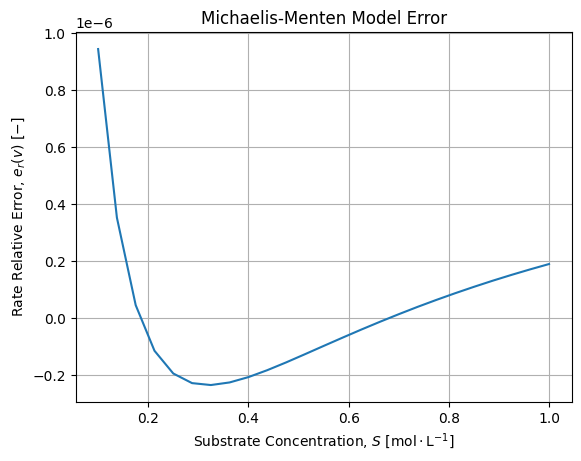

In [15]:
fig, axe = plt.subplots()
axe.plot(Ss, (vhat - vs) / vs)
axe.set_title("Michaelis-Menten Model Error")
axe.set_xlabel("Substrate Concentration, $S$ $[\mathrm{mol \cdot L^{-1}}]$")
axe.set_ylabel("Rate Relative Error, $e_r(v)$ $[-]$")
axe.grid()

In [16]:
popt

array([1.00000091e-09, 1.10000990e-01])

In [17]:
kM = (ks[1] + ks[2]) / ks[0]
kM

np.float64(0.10999999999999999)

In [18]:
vmax = ks[2] * x0[0]
vmax

np.float64(1e-09)

In [19]:
def linear(x, a, b):
    return a * x + b

In [22]:
poptL, pcovL = optimize.curve_fit(linear, 1 / Ss, 1 / vs)

In [23]:
poptL

array([1.10001023e+08, 9.99998789e+08])

In [25]:
vmaxL = 1. / poptL[1]
vmaxL

np.float64(1.0000012109137886e-09)

In [27]:
kML = poptL[0] * vmaxL
kML

np.float64(0.11000115659131006)

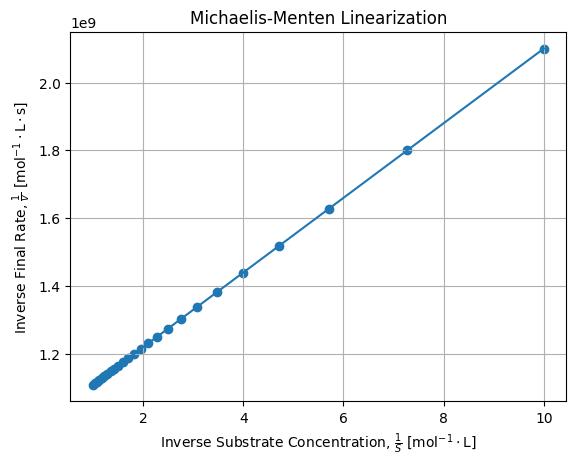

In [28]:
fig, axe = plt.subplots()
axe.scatter(1 / Ss, 1 / vs)
axe.plot(1 / Ss, linear(1 / Ss, *poptL))
axe.set_title("Michaelis-Menten Linearization")
axe.set_xlabel(r"Inverse Substrate Concentration, $\frac{1}{S}$ $[\mathrm{mol^{-1} \cdot L}]$")
axe.set_ylabel(r"Inverse Final Rate, $\frac{1}{v}$ $[\mathrm{mol^{-1} \cdot L \cdot s}]$")
axe.grid()